<a href="https://colab.research.google.com/github/dgarciav27/LLM-basics/blob/main/composicion_residuos_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caracterizacion de composicion de residuos por area de mascara
Toma una foto de un area con residuos acumulados/mezclados -> detecta y segmenta cada residuo por tipo -> calcula el % de area ocupada por cada categoria -> genera un reporte tipo "plastico 20%, carton 10%, organico 15%...".

**Idea base:** en vez de contar puntos sobre una grilla manual (metodo clasico de composicion de residuos), usamos la mascara de segmentacion real de cada objeto detectado y sumamos pixeles por clase. Es una version automatizada del mismo principio, pero con precision de pixel en vez de muestreo por puntos.


## 1. Instalar dependencias

In [1]:
!pip install -q roboflow ultralytics opencv-python-headless pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.2 MB/s eta 0:00:00


## 2. Descargar dataset desde Roboflow
Cambio clave respecto a tu snippet original: uso formato `"yolov11"` en vez de `"coco-segmentation"`. Ese formato entrega directo los `.txt` de poligono + `data.yaml`, listos para entrenar con `ultralytics` sin conversion manual.

**Seguridad:** guarda tu API key en Colab Secrets (icono de llave 🔑 en el panel izquierdo, nombre `ROBOFLOW_API_KEY`) en vez de pegarla en texto plano. Si ya la compartiste en algun chat/mensaje, regenerala en Roboflow (Settings > API Keys) por las dudas.

In [2]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = "BNuOMncf1WelnBAihUMf"  # la que veas activa en Settings > API Keys ahora mismo

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("danielas-workspace-yst6n").project("trash-fjusi-tsz7m")
dataset = download("yolov11")

print("Dataset descargado en:", dataset.location)


loading Roboflow workspace...
loading Roboflow project...


NameError: name 'download' is not defined

In [3]:
# Descargamos el archivo zip usando tu enlace
!curl -L "https://app.roboflow.com/ds/N3YuY9rqGO?key=IZ3tqBqvEk" > roboflow.zip

# Descomprimimos el archivo en una carpeta llamada "dataset" (la bandera -q es para que no imprima todo el texto)
!unzip -q roboflow.zip -d dataset

# Borramos el zip original para ahorrar espacio
!rm roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   928  100   928    0     0   2125      0 --:--:-- --:--:-- --:--:--  2123
100 64.2M  100 64.2M    0     0  28.1M      0  0:00:02  0:00:02 --:--:-- 54.4M
replace dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## 3. Entrenar (o continuar) el modelo de segmentacion
Si ya entrenaste dentro de Roboflow y te dio ~90%, puedes bajar esos pesos entrenados en vez de reentrenar desde cero — Roboflow te deja exportar el `.pt` del modelo entrenado en la plataforma. Si prefieres entrenar aca directo con `ultralytics` (mas control, mismo dataset), esta celda lo hace con YOLO11-seg.

In [4]:
from ultralytics import YOLO
dataset_path = "/content/dataset"
model = YOLO("yolo11n-seg.pt")  # segmentacion preentrenada, nano (rapido). sube a "s" o "m" si tienes GPU y quieres mas precision

results = model.train(
    task="segment",
    data=f"{dataset_path}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="trash_composicion"
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0

## 4. Cargar el mejor modelo entrenado
Ultralytics guarda automaticamente el mejor checkpoint. Si vienes de la celda anterior, ya esta en `results`; si vas a usar un modelo ya entrenado antes (de una corrida previa o exportado de Roboflow), carga el `.pt` directo.

In [5]:
BEST_WEIGHTS = "runs/segment/trash_composicion/weights/best.pt"
# si tienes un modelo ya entrenado de una corrida anterior, cambia la ruta de arriba,
# por ejemplo: BEST_WEIGHTS = "/content/drive/MyDrive/modelos/trash_best.pt"

model_final = YOLO(BEST_WEIGHTS)
print("Clases del modelo:", model_final.names)


Clases del modelo: {0: 'Battery', 1: 'Clothing', 2: 'General trash', 3: 'Glass', 4: 'Metal', 5: 'Paper', 6: 'Paper pack', 7: 'Plastic', 8: 'Plastic bag', 9: 'Styrofoam'}


## 5. Funcion de analisis de composicion por area
Corre segmentacion sobre una foto, suma el area (en pixeles) de la mascara de cada instancia agrupada por clase, y calcula el porcentaje de cada tipo de residuo **relativo al area total cubierta por residuos detectados** (no relativo a la imagen completa, porque el fondo/piso no es residuo y distorsionaria el porcentaje).

Tambien guarda:
- una imagen con las mascaras superpuestas (para verificar visualmente)
- un reporte en texto y como diccionario/CSV (para usar en tu tesis o en un dashboard despues)

In [6]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def analizar_composicion(image_path, model, conf=0.3, guardar_en=None):
    """Devuelve un DataFrame con el % de area por clase y guarda una visualizacion."""
    resultado = model.predict(image_path, conf=conf, verbose=False)[0]

    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]

    area_por_clase = {}

    if resultado.masks is not None:
        masks = resultado.masks.data.cpu().numpy()       # (n_instancias, mh, mw) binario 0/1
        clases_ids = resultado.boxes.cls.cpu().numpy().astype(int)

        overlay = img.copy()
        rng = np.random.default_rng(42)
        color_por_clase = {}

        for mask, clase_id in zip(masks, clases_ids):
            nombre_clase = model.names[clase_id]

            # la mascara puede venir en resolucion distinta a la imagen original, se reescala
            mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
            area_px = int(mask_resized.sum())
            area_por_clase[nombre_clase] = area_por_clase.get(nombre_clase, 0) + area_px

            if nombre_clase not in color_por_clase:
                color_por_clase[nombre_clase] = rng.integers(0, 255, size=3).tolist()
            color = color_por_clase[nombre_clase]

            mask_bool = mask_resized.astype(bool)
            overlay[mask_bool] = (
                0.5 * np.array(color) + 0.5 * overlay[mask_bool]
            ).astype(np.uint8)

        if guardar_en:
            cv2.imwrite(str(guardar_en), overlay)
    else:
        print("No se detecto ningun residuo en la imagen (revisa el umbral 'conf' o la calidad de la foto).")

    area_total = sum(area_por_clase.values())
    if area_total == 0:
        return pd.DataFrame(columns=["clase", "area_px", "porcentaje"])

    filas = []
    for clase, area in sorted(area_por_clase.items(), key=lambda x: -x[1]):
        filas.append({
            "clase": clase,
            "area_px": area,
            "porcentaje": round(100 * area / area_total, 1)
        })

    df = pd.DataFrame(filas)
    return df, overlay if resultado.masks is not None else None


## 6. Correr el analisis sobre una foto y generar el reporte

=== Reporte de composicion de residuos ===
Plastic bag: 47.6%  (38568 px)
Paper: 29.3%  (23735 px)
Plastic: 18.2%  (14762 px)
Styrofoam: 4.9%  (3938 px)


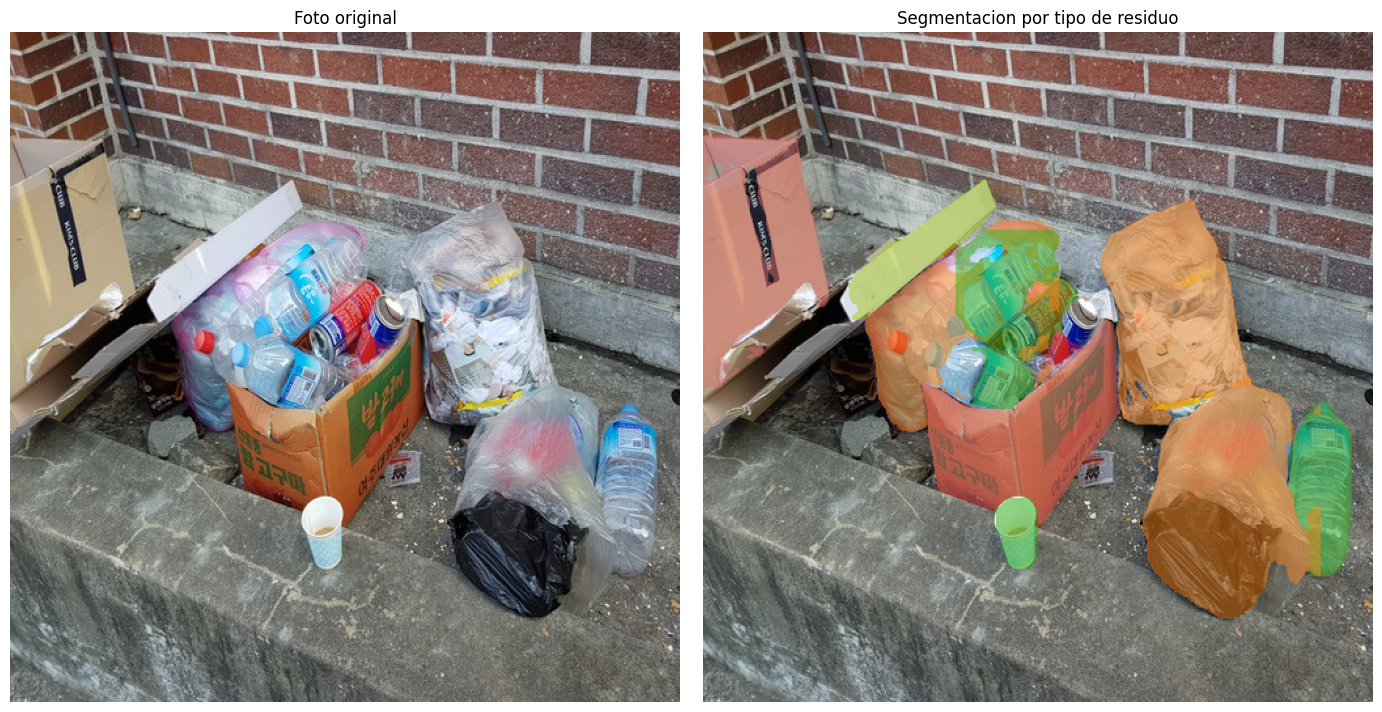

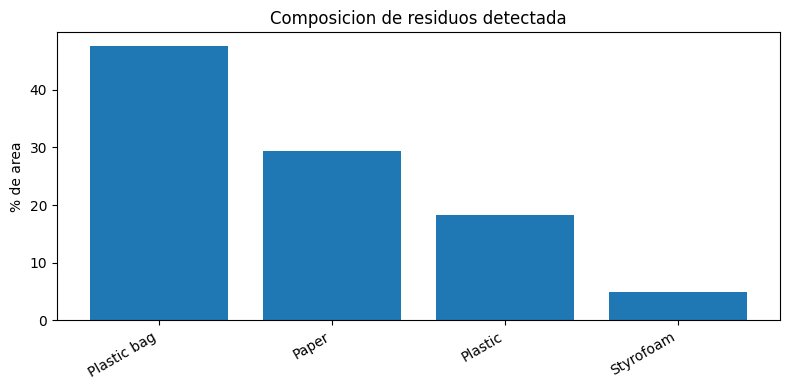


Reporte guardado en reporte_composicion.csv


In [7]:
IMAGEN_A_ANALIZAR = "/content/dataset/valid/images/00991_jpg.rf.ztKZgeIIoqKZO0X1Mnvn.jpg"  # sube tu foto a Colab (icono de carpeta a la izquierda) y pega la ruta aca

df_composicion, overlay = analizar_composicion(
    IMAGEN_A_ANALIZAR,
    model_final,
    conf=0.3,
    guardar_en="overlay_resultado.jpg"
)

print("=== Reporte de composicion de residuos ===")
for _, fila in df_composicion.iterrows():
    print(f"{fila['clase']}: {fila['porcentaje']}%  ({fila['area_px']} px)")

# visualizacion lado a lado: original vs mascara superpuesta
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
axs[0].imshow(cv2.cvtColor(cv2.imread(IMAGEN_A_ANALIZAR), cv2.COLOR_BGR2RGB))
axs[0].set_title("Foto original")
axs[0].axis("off")

axs[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axs[1].set_title("Segmentacion por tipo de residuo")
axs[1].axis("off")
plt.tight_layout()
plt.show()

# grafico de barras del reporte
plt.figure(figsize=(8, 4))
plt.bar(df_composicion["clase"], df_composicion["porcentaje"])
plt.ylabel("% de area")
plt.title("Composicion de residuos detectada")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

df_composicion.to_csv("reporte_composicion.csv", index=False)
print("\nReporte guardado en reporte_composicion.csv")


In [8]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def analizar_composicion(image_path, model, conf=0.3, guardar_en=None):
    """Devuelve un DataFrame con % de area, conteo de instancias por clase,
    y una imagen con mascaras + bounding boxes superpuestos."""
    resultado = model.predict(image_path, conf=conf, verbose=False)[0]

    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]

    area_por_clase = {}
    conteo_por_clase = {}
    overlay = img.copy()

    if resultado.masks is not None:
        masks = resultado.masks.data.cpu().numpy()
        clases_ids = resultado.boxes.cls.cpu().numpy().astype(int)
        confidencias = resultado.boxes.conf.cpu().numpy()
        boxes_xyxy = resultado.boxes.xyxy.cpu().numpy()

        rng = np.random.default_rng(42)
        color_por_clase = {}

        # 1. dibuja las mascaras primero (semi-transparentes, van "debajo")
        for mask, clase_id in zip(masks, clases_ids):
            nombre_clase = model.names[clase_id]
            mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
            area_px = int(mask_resized.sum())
            area_por_clase[nombre_clase] = area_por_clase.get(nombre_clase, 0) + area_px
            conteo_por_clase[nombre_clase] = conteo_por_clase.get(nombre_clase, 0) + 1

            if nombre_clase not in color_por_clase:
                color_por_clase[nombre_clase] = rng.integers(0, 255, size=3).tolist()
            color = color_por_clase[nombre_clase]

            mask_bool = mask_resized.astype(bool)
            overlay[mask_bool] = (
                0.5 * np.array(color) + 0.5 * overlay[mask_bool]
            ).astype(np.uint8)

        # 2. dibuja los bounding boxes + etiquetas encima de las mascaras
        for box, clase_id, conf_score in zip(boxes_xyxy, clases_ids, confidencias):
            nombre_clase = model.names[clase_id]
            color = color_por_clase[nombre_clase]
            x1, y1, x2, y2 = box.astype(int)

            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
            etiqueta = f"{nombre_clase} {conf_score:.2f}"
            (tw, th), _ = cv2.getTextSize(etiqueta, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(overlay, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
            cv2.putText(overlay, etiqueta, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        if guardar_en:
            cv2.imwrite(str(guardar_en), overlay)
    else:
        print("No se detecto ningun residuo en la imagen (revisa el umbral 'conf' o la calidad de la foto).")
        return pd.DataFrame(columns=["clase", "conteo", "area_px", "porcentaje"]), overlay

    area_total = sum(area_por_clase.values())
    total_instancias = sum(conteo_por_clase.values())

    filas = []
    for clase in area_por_clase:
        filas.append({
            "clase": clase,
            "conteo": conteo_por_clase[clase],
            "area_px": area_por_clase[clase],
            "porcentaje": round(100 * area_por_clase[clase] / area_total, 1)
        })

    df = pd.DataFrame(filas).sort_values("porcentaje", ascending=False).reset_index(drop=True)
    print(f"Total de residuos detectados: {total_instancias} instancias")
    return df, overlay

Total de residuos detectados: 11 instancias
=== Reporte de composicion de residuos ===
Plastic bag: 3 objetos | 47.6% de area  (38568 px)
Paper: 2 objetos | 29.3% de area  (23735 px)
Plastic: 5 objetos | 18.2% de area  (14762 px)
Styrofoam: 1 objetos | 4.9% de area  (3938 px)


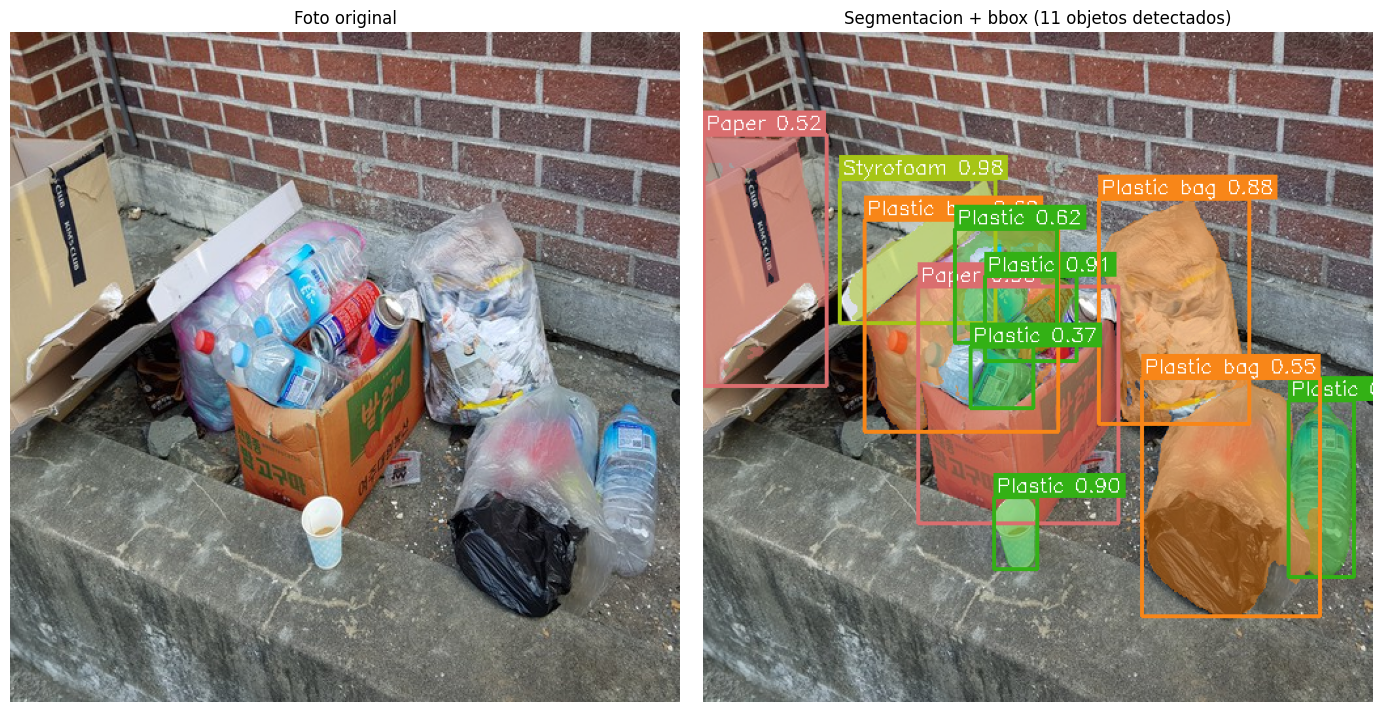

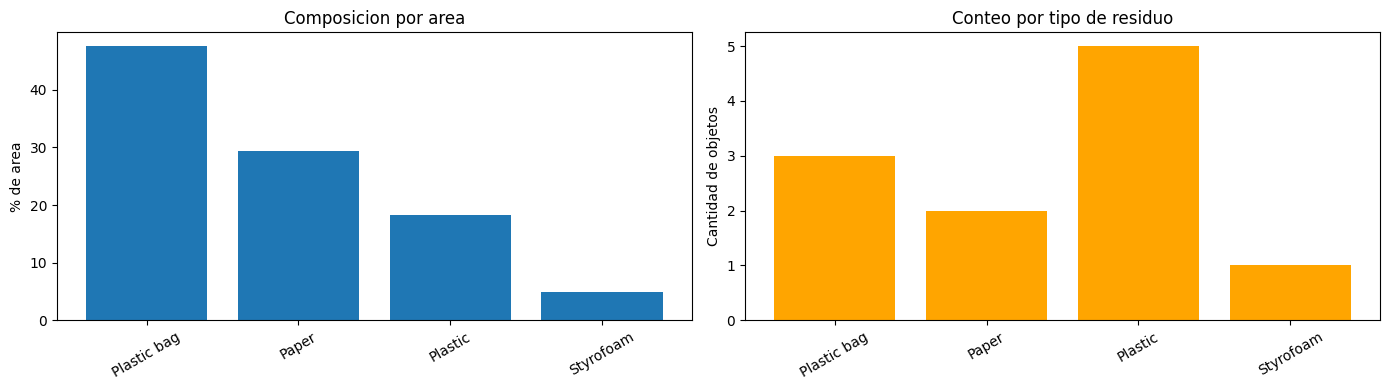


Reporte guardado en reporte_composicion.csv


In [9]:
IMAGEN_A_ANALIZAR = "/content/dataset/valid/images/00991_jpg.rf.ztKZgeIIoqKZO0X1Mnvn.jpg"

df_composicion, overlay = analizar_composicion(
    IMAGEN_A_ANALIZAR,
    model_final,
    conf=0.3,
    guardar_en="overlay_resultado.jpg"
)

print("=== Reporte de composicion de residuos ===")
for _, fila in df_composicion.iterrows():
    print(f"{fila['clase']}: {fila['conteo']} objetos | {fila['porcentaje']}% de area  ({fila['area_px']} px)")

# visualizacion lado a lado: original vs mascara + bbox
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
axs[0].imshow(cv2.cvtColor(cv2.imread(IMAGEN_A_ANALIZAR), cv2.COLOR_BGR2RGB))
axs[0].set_title("Foto original")
axs[0].axis("off")

axs[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axs[1].set_title(f"Segmentacion + bbox ({df_composicion['conteo'].sum()} objetos detectados)")
axs[1].axis("off")
plt.tight_layout()
plt.show()

# grafico de barras: porcentaje de area
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].bar(df_composicion["clase"], df_composicion["porcentaje"])
axs[0].set_ylabel("% de area")
axs[0].set_title("Composicion por area")
axs[0].tick_params(axis="x", rotation=30)

# grafico de barras: conteo de instancias
axs[1].bar(df_composicion["clase"], df_composicion["conteo"], color="orange")
axs[1].set_ylabel("Cantidad de objetos")
axs[1].set_title("Conteo por tipo de residuo")
axs[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

df_composicion.to_csv("reporte_composicion.csv", index=False)
print("\nReporte guardado en reporte_composicion.csv")

## 7. (Opcional) Validacion cruzada con grilla
Tu idea de dividir la imagen en grilla es valida como **chequeo de sanidad**, no como metodo principal — con mascaras de segmentacion ya tienes el area exacta, una grilla solo aproximaria eso con menos precision. Pero puede servir para comparar visualmente si el area por mascara "tiene sentido" respecto a una particion simple de la imagen, o para detectar zonas de la foto donde el modelo no esta detectando nada (esquinas oscuras, residuos muy pequenos, etc.).

In [10]:
def grilla_cobertura(image_path, model, filas=4, columnas=4, conf=0.3):
    """Divide la imagen en una grilla y reporta cuantas celdas tienen al menos una deteccion,
    util como chequeo rapido de cobertura, no reemplaza el calculo de area por mascara."""
    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]
    resultado = model.predict(image_path, conf=conf, verbose=False)[0]

    celdas_con_deteccion = np.zeros((filas, columnas), dtype=bool)

    if resultado.masks is not None:
        masks = resultado.masks.data.cpu().numpy()
        for mask in masks:
            mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
            ys, xs = np.where(mask_resized > 0)
            if len(ys) == 0:
                continue
            fila_idx = (ys * filas // h).clip(0, filas - 1)
            col_idx = (xs * columnas // w).clip(0, columnas - 1)
            for fi, ci in zip(fila_idx, col_idx):
                celdas_con_deteccion[fi, ci] = True

    cobertura_pct = 100 * celdas_con_deteccion.sum() / (filas * columnas)
    print(f"Cobertura de deteccion: {cobertura_pct:.1f}% de la grilla ({filas}x{columnas}) tiene al menos un residuo detectado")
    return celdas_con_deteccion

_ = grilla_cobertura(IMAGEN_A_ANALIZAR, model_final)


Cobertura de deteccion: 81.2% de la grilla (4x4) tiene al menos un residuo detectado


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import shutil, os

carpeta_drive = "/content/drive/MyDrive/analisis_residuos_tesis"
os.makedirs(carpeta_drive, exist_ok=True)

# copia los archivos sueltos que ya tenias
shutil.copy("reporte_composicion.csv", carpeta_drive)
shutil.copy("overlay_resultado.jpg", carpeta_drive)

# copia la carpeta /content/runs completa (con subcarpetas: weights, results.csv, graficos, etc.)
destino_runs = f"{carpeta_drive}/runs"
if os.path.exists(destino_runs):
    shutil.rmtree(destino_runs)  # evita error si ya existe una copia previa
shutil.copytree("/content/runs", destino_runs)

print(f"Archivos copiados a: {carpeta_drive}")
print(f"Carpeta runs copiada a: {destino_runs}")

Archivos copiados a: /content/drive/MyDrive/analisis_residuos_tesis
Carpeta runs copiada a: /content/drive/MyDrive/analisis_residuos_tesis/runs


## Notas para tu tesis

- **El area por mascara es el metodo principal**, no la grilla — es mas preciso porque usa el pixel exacto, no una aproximacion por celdas. La grilla es solo para chequeo visual rapido.
- **Limitacion importante a declarar:** el % es de **area proyectada 2D**, no de masa/volumen real. Residuos livianos y planos (film plastico, papel) tienden a ocupar mas area relativa de la que representan en peso — es la misma limitacion que reportan los estudios clasicos de composicion de residuos por imagen, que society corrigen esto con factores de densidad por material (peso/volumen conocido de cada tipo de residuo) para convertir area a una estimacion de masa. Si tu tesis necesita %  en peso y no solo en area, este es el siguiente paso natural: multiplicar el area de cada clase por una densidad promedio conocida del material.
- **Oclusion:** si un residuo esta parcialmente tapado por otro, el area medida es la visible, no la real total del objeto — es una limitacion inherente a cualquier metodo de imagen 2D, vale la pena mencionarla explicitamente en la metodologia.
- **Reporta el `conf` (umbral de confianza)** que uses en el analisis final — cambiar ese numero cambia cuantas instancias chicas o dudosas se cuentan, y afecta el porcentaje final.
